In [9]:
# Data を読み込んでみる
import pandas as pd

df_info = pd.read_csv('MathProgramming/Chapter1/accomodation_info.csv', index_col=0, parse_dates=[0])
df_info

,顧客ID,宿泊者名,プラン,金額
日時,,,,
2018-11-01 00:02:21,110034,若松 花子,B,19000
2018-11-01 00:03:10,112804,津田 美加子,D,20000
2018-11-01 00:06:19,110275,吉本 美加子,D,20000
2018-11-01 00:08:41,110169,坂本 直人,B,19000
2018-11-01 00:12:22,111504,青山 零,A,15000
...,...,...,...,...
2020-10-31 23:38:51,110049,吉本 篤司,A,3000
2020-10-31 23:42:12,110127,喜嶋 浩,A,3000
2020-10-31 23:47:24,115464,藤本 明美,D,8000


#### 宿泊料金
曜日や季節によって変動する場合があり、特にコロナウイルス感染症の流行後は大幅な値下げを行なっている。
#### 宿泊 Plan
A: 素泊まり
B: 朝夕食付き
C: 素泊まり露天風呂付客室
D: 朝夕食付き露天風呂付客室

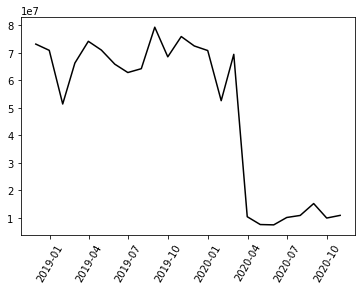

In [10]:
# 時系列 Data を可視化してみる
import matplotlib.pyplot as plt

# 月ごとの売上
plt.plot(df_info['金額'].resample('M').sum(), color='k')
plt.xticks(rotation=60)
plt.show()

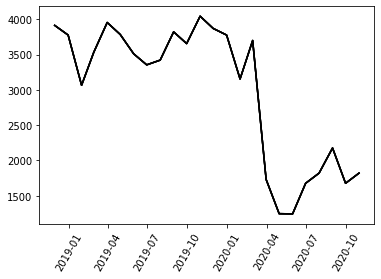

In [11]:
# 月ごとの利用者数
plt.plot(df_info.resample('M').count(), color='k')
plt.xticks(rotation=60)
plt.show()

売上も利用者（宿泊者）も、感染症流行を経て激減していることがわかる。

In [12]:
# 平均値、中央値、最小値、最大値を出力
x_mean = df_info['顧客ID'].value_counts().mean()
x_median = df_info['顧客ID'].value_counts().median()
x_min = df_info['顧客ID'].value_counts().min()
x_max = df_info['顧客ID'].value_counts().max()
print('平均値:', x_mean)
print('中央値:', x_median)
print('最小値:', x_min)
print('最大値:', x_max)

平均値: 13.073641997812613
中央値: 7.0
最小値: 1
最大値: 184


- **平均値が13回なのに対して中央値が７回と値がズレている。**
利用者の利用回数が一様に分布していれば平均値と中央値は概ね一致するが、利用回数が少ない人が多く、利用回数が多い人がまばらに分布していると分布に偏りが見られる場合、平均値と中央値にズレが生じているのではないかと考えることができる。

- **最小値が１なのに対し最大値が184、最小値が13に近い値なのに対して最大値は184と、平均値から遠い位置にある**
最小値に近いところに利用回数が集中していて、最大値に近いところはまだらに点在しているのではないかと予想できる

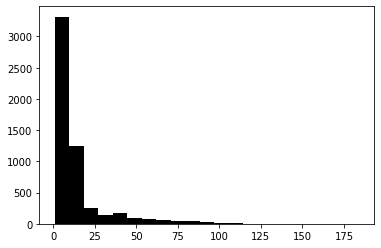

In [13]:
x = df_info['顧客ID'].value_counts()
x_hist, t_hist, _ = plt.hist(x, 21, color='k')
plt.show()

左端に Data が集中している様子が確認とれる。
ほとんどの利用者がごく少数の利用のみで０付近に週通するが、少数だけ極めて多い回数の利用者が存在し、平均値が最小値側に大幅に偏っていた理由だったことがわかる。

現在、分析している Data がどのような数式に基づく分布に従うか Histogram上に「**近似曲線**」を引くことで、実際にべき分布をしている、ということを説得力高く示す。

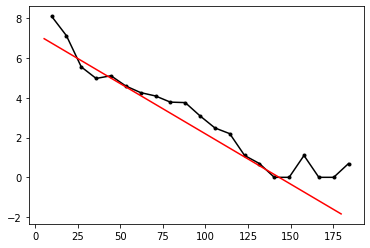

In [20]:
# 近似曲線の Parameter を算出する
import numpy as np

# Params 設定
epsilon = 1
num = 15

# 変数設定
weight = x_hist[1:num]
t = np.zeros(len(t_hist) - 1)
for i in range(len(t_hist) - 1):
    t[i] = (t_hist[i] + t_hist[i + 1]) / 2

# Fitting（最小二乗近似）による Parameter の算出
a, b = np.polyfit(t[1:num], np.log(x_hist[1:num]), 1)

# Fitting曲線（直線）の描画
xt = np.zeros(len(t))
for i in range(len(t)):
    xt[i] = a * t[i] + b

plt.plot(t_hist[1:], np.log(x_hist + epsilon), marker='.', color='k')
plt.plot(t, xt, color='r')
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

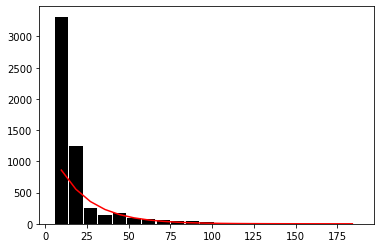

In [21]:
# 近似曲線を描く
import math

t = t_hist[1:]
xt = np.zeros(len(t))
for i in range(len(t)):
    xt[i] = math.exp(a * t[i] + b)

plt.bar(t_hist[1:], x_hist, width=8, color='k')
plt.plot(t, xt, color='r')
plt.show

近似曲線を描く場合は、
- なぜその曲線を描いたのか
- どのように描いたのか
- その曲線によってどのような意味を伝えたいのか

ということが重要。

描いた近似曲線を自分自身で理解していなと
- Data に対する誤った理解
- 顧客への誤った理解の報告 = 信用の失墜

に繋がってしまう。